# Step 2：数据质量验证

## 业务问题

2015年10月留存下降是否只是数据缺失、日期异常、观察窗口不足、重复记录或计算逻辑造成的假异常？本步骤只验证数据健康，不讨论业务原因。


In [1]:
from pathlib import Path
import time
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
run_started = time.perf_counter()
project_dir = Path.cwd().resolve()
if project_dir.name == 'notebooks': project_dir = project_dir.parent
raw_dir, processed_dir, outputs_dir = project_dir/'data'/'raw', project_dir/'data'/'processed', project_dir/'outputs'
CHUNK_SIZE = 1_000_000
raw_files = sorted(raw_dir.glob('*.csv'))
raw_before = {p.name:(p.stat().st_size,p.stat().st_mtime_ns) for p in raw_files}
members_raw = pd.read_csv(raw_dir/'members_v3.csv', usecols=['msno','registration_init_time'], dtype='object')
members_raw['registration_date'] = pd.to_datetime(members_raw['registration_init_time'], format='%Y%m%d', errors='coerce')
invalid_registration_dates = int(members_raw['registration_date'].isna().sum())
global_dup_rows = int(members_raw['msno'].duplicated(keep=False).sum())
global_dup_users = int(members_raw.loc[members_raw['msno'].duplicated(keep=False),'msno'].nunique())
cohort_members = members_raw.loc[members_raw['registration_date'].between('2015-07-01','2015-10-31'), ['msno','registration_date']].copy()
scoped_dup_rows = int(cohort_members['msno'].duplicated(keep=False).sum())
scoped_dup_users = int(cohort_members.loc[cohort_members['msno'].duplicated(keep=False),'msno'].nunique())
cohort_members = cohort_members.drop_duplicates('msno').reset_index(drop=True)
cohort_members['registration_month'] = cohort_members['registration_date'].dt.to_period('M').astype(str)
registration_daily = (cohort_members.groupby('registration_date')['msno'].nunique().reindex(pd.date_range('2015-07-01','2015-10-31'),fill_value=0).rename('registered_users').rename_axis('registration_date').reset_index())
oct_daily = registration_daily[registration_daily.registration_date.dt.month.eq(10)].copy()
q1,q3 = oct_daily.registered_users.quantile([.25,.75]); iqr=q3-q1; cutoff=q3+1.5*iqr
oct_high_days = oct_daily[oct_daily.registered_users.gt(cutoff)].sort_values('registered_users',ascending=False)
print(f'Invalid registration dates (full file): {invalid_registration_dates:,}')
print(f'Duplicate msno rows/users (full file): {global_dup_rows:,}/{global_dup_users:,}')
print(f'Duplicate msno rows/users (Jul-Oct): {scoped_dup_rows:,}/{scoped_dup_users:,}')
print('\nMonthly registrations:'); print(cohort_members.groupby('registration_month').msno.nunique().to_string())
print(f'\nOctober median={oct_daily.registered_users.median():.0f}, IQR={iqr:.0f}, outlier cutoff={cutoff:.0f}')
print('October high-outlier days:'); print(oct_high_days.to_string(index=False) if len(oct_high_days) else 'None')
print('\nDaily registration table:'); print(registration_daily.to_string(index=False))

Invalid registration dates (full file): 0
Duplicate msno rows/users (full file): 0/0
Duplicate msno rows/users (Jul-Oct): 0/0

Monthly registrations:


registration_month
2015-07    111526
2015-08    161470
2015-09    119370
2015-10    235884

October median=7551, IQR=1898, outlier cutoff=11730
October high-outlier days:
registration_date  registered_users
       2015-10-09             12413

Daily registration table:
registration_date  registered_users
       2015-07-01              3530
       2015-07-02              3398
       2015-07-03              3478
       2015-07-04              3851
       2015-07-05              3320
       2015-07-06              3750
       2015-07-07              3936
       2015-07-08              3654
       2015-07-09              3426
       2015-07-10              3841
       2015-07-11              3927
       2015-07-12              3306
       2015-07-13              3764
       2015-07-14              3320
       2015-07-15              3426
       2015-07-16              3234
       2015-07-17              3331
       2015-07-18              4127
       2015-07-19              4119
       201

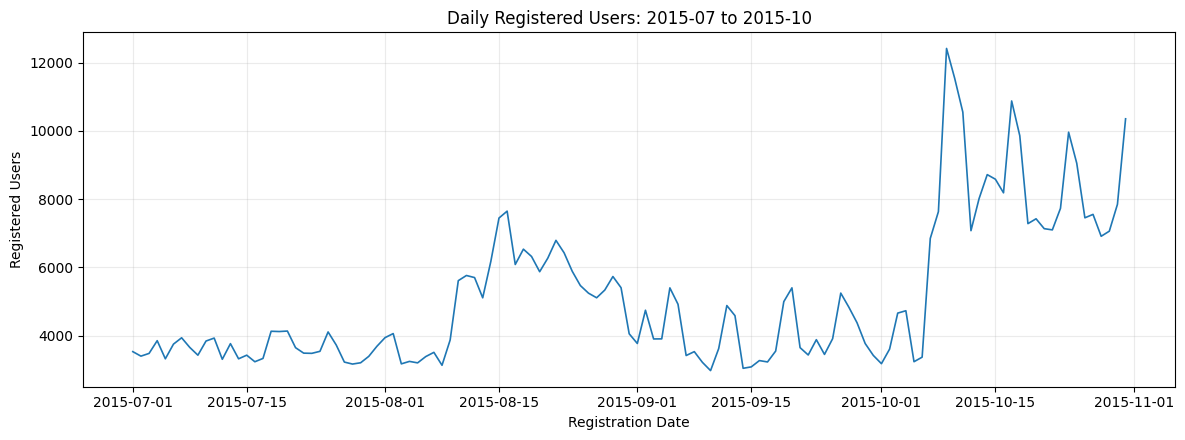

In [2]:
fig,ax=plt.subplots(figsize=(12,4.5)); ax.plot(registration_daily.registration_date,registration_daily.registered_users,linewidth=1.2)
ax.set(xlabel='Registration Date',ylabel='Registered Users',title='Daily Registered Users: 2015-07 to 2015-10'); ax.grid(alpha=.25); fig.tight_layout()
registration_plot_path=outputs_dir/'registration_daily_check.png'; fig.savefig(registration_plot_path,dpi=150); plt.show()

## Chunked log checks and independent retention reproduction

Only `msno` and `date` are read. Two independent stable 64-bit hashes provide a memory-safe user identifier for user-date distinct and duplicate counts.

In [3]:
cohort_members['d7_target']=(cohort_members.registration_date+pd.Timedelta(days=7)).dt.strftime('%Y%m%d').astype('int32')
cohort_members['d30_target']=(cohort_members.registration_date+pd.Timedelta(days=30)).dt.strftime('%Y%m%d').astype('int32')
cohort_members['d7_eligible']=(cohort_members.registration_date+pd.Timedelta(days=7)).le('2017-03-31')
cohort_members['d30_eligible']=(cohort_members.registration_date+pd.Timedelta(days=30)).le('2017-03-31')
member_id=pd.Series(np.arange(len(cohort_members),dtype=np.int32),index=cohort_members.msno)
d7_target=cohort_members.d7_target.to_numpy('int32'); d30_target=cohort_members.d30_target.to_numpy('int32')
d7_retained=np.zeros(len(cohort_members),bool); d30_retained=np.zeros(len(cohort_members),bool)
daily_rows=defaultdict(int); daily_hash_parts=defaultdict(list); rows_scanned=relevant_rows=chunks_scanned=0

In [4]:
scan_started=time.perf_counter()
reader=pd.read_csv(raw_dir/'user_logs.csv',usecols=['msno','date'],dtype={'msno':'object','date':'int32'},chunksize=CHUNK_SIZE)
for chunk in reader:
    rows_scanned+=len(chunk); chunks_scanned+=1
    relevant=chunk[chunk.date.between(20150701,20151130)]
    if len(relevant):
        relevant_rows+=len(relevant)
        for day,n in relevant.date.value_counts().items(): daily_rows[int(day)]+=int(n)
        for day,s in relevant.groupby('date',sort=False).msno:
            h1=pd.util.hash_pandas_object(s,index=False,hash_key='0123456789abcdef').to_numpy('uint64')
            h2=pd.util.hash_pandas_object(s,index=False,hash_key='fedcba9876543210').to_numpy('uint64')
            daily_hash_parts[int(day)].append((h1,h2))
    mapped=chunk.msno.map(member_id); valid=mapped.notna().to_numpy()
    if valid.any():
        ids=mapped.to_numpy()[valid].astype('int32',copy=False); dates=chunk.date.to_numpy('int32',copy=False)[valid]
        hit7=dates==d7_target[ids]; hit30=dates==d30_target[ids]
        if hit7.any(): d7_retained[ids[hit7]]=True
        if hit30.any(): d30_retained[ids[hit30]]=True
    if chunks_scanned%25==0: print(f'{rows_scanned:,} rows scanned')
print(f'Scanned {rows_scanned:,} rows in {chunks_scanned} chunks; relevant rows={relevant_rows:,}; minutes={(time.perf_counter()-scan_started)/60:.2f}')

25,000,000 rows scanned


50,000,000 rows scanned


75,000,000 rows scanned


100,000,000 rows scanned


125,000,000 rows scanned


...

300,000,000 rows scanned


325,000,000 rows scanned


350,000,000 rows scanned


375,000,000 rows scanned


Scanned 392,106,543 rows in 393 chunks; relevant rows=68,947,581; minutes=6.90


In [5]:
dates=pd.date_range('2015-07-01','2015-11-30'); log_daily=pd.DataFrame({'log_date':dates})
log_daily['date_int']=log_daily.log_date.dt.strftime('%Y%m%d').astype('int32'); log_daily['log_rows']=log_daily.date_int.map(daily_rows).fillna(0).astype('int64')
active={}; unique_total=duplicate_combinations=0; duplicate_users=set(); pair_dtype=np.dtype([('h1','<u8'),('h2','<u8')])
for day in log_daily.date_int:
    parts=daily_hash_parts.get(int(day),[])
    if not parts: active[int(day)]=0; continue
    h1=np.concatenate([x[0] for x in parts]); h2=np.concatenate([x[1] for x in parts]); pairs=np.empty(len(h1),dtype=pair_dtype); pairs['h1']=h1; pairs['h2']=h2
    unique,counts=np.unique(pairs,return_counts=True); active[int(day)]=len(unique); unique_total+=len(unique)
    dup=unique[counts>1]; duplicate_combinations+=len(dup); duplicate_users.update((int(x['h1']),int(x['h2'])) for x in dup)
log_daily['active_users']=log_daily.date_int.map(active).fillna(0).astype('int64')
missing=log_daily[log_daily.log_rows.eq(0)].log_date
log_daily['rows_ratio_7d']=log_daily.log_rows/log_daily.log_rows.rolling(7,center=True,min_periods=4).median()
log_daily['users_ratio_7d']=log_daily.active_users/log_daily.active_users.rolling(7,center=True,min_periods=4).median()
near_zero=log_daily[(log_daily.rows_ratio_7d<.2)|(log_daily.users_ratio_7d<.2)]
log_daily['rows_change']=log_daily.log_rows.pct_change(); log_daily['users_change']=log_daily.active_users.pct_change()
monthly_logs=log_daily.assign(month=log_daily.log_date.dt.to_period('M').astype(str)).groupby('month').agg(log_rows=('log_rows','sum'),active_user_days=('active_users','sum'),avg_daily_log_rows=('log_rows','mean'),avg_daily_active_users=('active_users','mean'))
print(f'Missing dates ({len(missing)}): {missing.dt.strftime("%Y-%m-%d").tolist()}')
print(f'Total logs: {relevant_rows:,}; unique msno+date: {unique_total:,}; duplicate combinations: {duplicate_combinations:,}; duplicate rows beyond first: {relevant_rows-unique_total:,}; duplicate users: {len(duplicate_users):,}')
print('\nNear-zero days:'); print(near_zero.to_string(index=False) if len(near_zero) else 'None')
print('\nSteepest log-row changes:'); print(log_daily.nsmallest(5,'rows_change')[['log_date','log_rows','rows_change']].to_string(index=False))
print('\nSteepest active-user changes:'); print(log_daily.nsmallest(5,'users_change')[['log_date','active_users','users_change']].to_string(index=False))
print('\nMonthly logs:'); print(monthly_logs.to_string()); print('\nDaily logs:'); print(log_daily[['log_date','log_rows','active_users']].to_string(index=False))

Missing dates (0): []
Total logs: 68,947,581; unique msno+date: 68,947,581; duplicate combinations: 0; duplicate rows beyond first: 0; duplicate users: 0

Near-zero days:
None

Steepest log-row changes:
  log_date  log_rows  rows_change
2015-08-08    353211    -0.162259
2015-09-28    409791    -0.060487
2015-11-14    460669    -0.055689
2015-09-27    436174    -0.044950
2015-09-26    456703    -0.034169

Steepest active-user changes:
  log_date  active_users  users_change
2015-08-08        353211     -0.162259
2015-09-28        409791     -0.060487
2015-11-14        460669     -0.055689
2015-09-27        436174     -0.044950
2015-09-26        456703     -0.034169

Monthly logs:
         log_rows  active_user_days  avg_daily_log_rows  avg_daily_active_users
month                                                                          
2015-07  13186484          13186484       425370.451613           425370.451613
2015-08  13428113          13428113       433164.935484           433164.

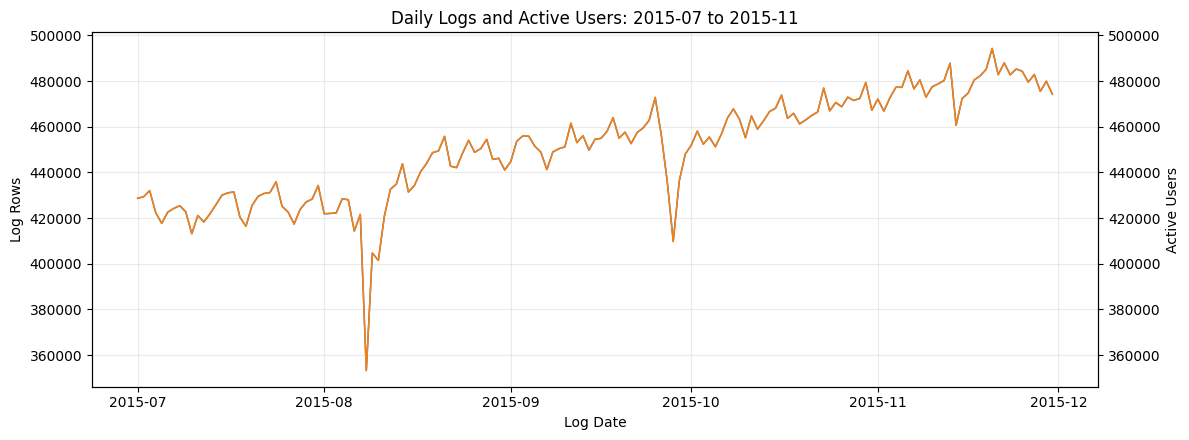

In [6]:
fig,ax1=plt.subplots(figsize=(12,4.5)); ax1.plot(log_daily.log_date,log_daily.log_rows,color='tab:blue',linewidth=1.1); ax1.set(xlabel='Log Date',ylabel='Log Rows',title='Daily Logs and Active Users: 2015-07 to 2015-11')
ax2=ax1.twinx(); ax2.plot(log_daily.log_date,log_daily.active_users,color='tab:orange',linewidth=1.1); ax2.set_ylabel('Active Users'); ax1.grid(alpha=.25); fig.tight_layout()
log_plot_path=outputs_dir/'log_daily_check.png'; fig.savefig(log_plot_path,dpi=150); plt.show()

In [7]:
cohort_members['d7_retained']=d7_retained&cohort_members.d7_eligible.to_numpy(); cohort_members['d30_retained']=d30_retained&cohort_members.d30_eligible.to_numpy()
recalc=cohort_members.groupby('registration_month',sort=True).agg(registered_users=('msno','size'),d7_eligible_users=('d7_eligible','sum'),d7_retained_users=('d7_retained','sum'),d30_eligible_users=('d30_eligible','sum'),d30_retained_users=('d30_retained','sum')).reset_index()
recalc['d7_retention_rate']=recalc.d7_retained_users/recalc.d7_eligible_users; recalc['d30_retention_rate']=recalc.d30_retained_users/recalc.d30_eligible_users
monitor=pd.read_csv(processed_dir/'cohort_retention_monitor.csv')
cols=['registration_month','registered_users','d7_eligible_users','d7_retained_users','d7_retention_rate','d30_eligible_users','d30_retained_users','d30_retention_rate']
comparison=recalc.merge(monitor[cols],on='registration_month',suffixes=('_recalc','_monitor'),validate='one_to_one')
comparison['d7_rate_diff']=comparison.d7_retention_rate_recalc-comparison.d7_retention_rate_monitor; comparison['d30_rate_diff']=comparison.d30_retention_rate_recalc-comparison.d30_retention_rate_monitor
count_cols=['registered_users','d7_eligible_users','d7_retained_users','d30_eligible_users','d30_retained_users']
counts_match=all((comparison[f'{c}_recalc']==comparison[f'{c}_monitor']).all() for c in count_cols); rates_match=np.allclose(comparison[['d7_rate_diff','d30_rate_diff']],0,atol=5e-7)
october=recalc[recalc.registration_month.eq('2015-10')].iloc[0]
print('2015-10 window:'); print(october[['registered_users','d7_eligible_users','d30_eligible_users']].to_string())
print('\nRecalculation:'); print(comparison[['registration_month','registered_users_recalc','d7_retained_users_recalc','d7_retention_rate_recalc','d30_retained_users_recalc','d30_retention_rate_recalc','d7_rate_diff','d30_rate_diff']].to_string(index=False))
print(f'Counts match={counts_match}; rates match={rates_match}')
assert int(october.registered_users)==int(october.d7_eligible_users)==int(october.d30_eligible_users)==235884
assert counts_match and rates_match, 'Independent retention calculation mismatch; stop.'
issues=[]
if len(missing): issues.append('missing dates')
if len(near_zero): issues.append('near-zero log volume')
final_decision=('Data issue found; pause: '+', '.join(issues)) if issues else '2015-10 retention decline cannot be explained by missing logs, insufficient observation windows, duplicate records, or changed calculation method; business-dimension decomposition may proceed.'
raw_after={p.name:(p.stat().st_size,p.stat().st_mtime_ns) for p in raw_files}; raw_unchanged=raw_before==raw_after; runtime=time.perf_counter()-run_started
print('\n'+final_decision); print(f'Registration plot: {registration_plot_path}'); print(f'Log plot: {log_plot_path}'); print(f'Total runtime: {runtime:.2f} seconds ({runtime/60:.2f} minutes)'); print(f'Raw files unchanged: {raw_unchanged}')
assert raw_unchanged

2015-10 window:
registered_users      235884
d7_eligible_users     235884
d30_eligible_users    235884

Recalculation:
registration_month  registered_users_recalc  d7_retained_users_recalc  d7_retention_rate_recalc  d30_retained_users_recalc  d30_retention_rate_recalc  d7_rate_diff  d30_rate_diff
           2015-07                   111526                     22534                  0.202052                      10789                   0.096740 -4.604487e-07  -2.263149e-07
           2015-08                   161470                     34885                  0.216046                      15354                   0.095089  3.243946e-07  -1.290023e-07
           2015-09                   119370                     27489                  0.230284                      13167                   0.110304 -9.047499e-09   9.650666e-08
           2015-10                   235884                     25890                  0.109757                      16866                   0.071501  3.383527e-07  

## 教程式结论与下一步

检查覆盖日志日期完整性、D30观察窗口、用户重复、user-date重复、留存指标独立复现、注册量日趋势及日志断流风险。

**结论：**未发现日志缺失、观察窗口不足、重复记录或指标口径问题，因此留存下降可视为真实分析异常，可以进入业务维度拆解。
